# AI Franchise Classification Analysis

**Purpose:** Classify California businesses as FRANCHISE or INDEPENDENT using OpenAI LLMs

This notebook uses AI to analyze business names, categories, and locations to determine franchise status. The classification helps identify market patterns, competitive landscapes, and business opportunities.

**Features:**
- **Two-tier AI classification** - Fast model first, advanced model for uncertain cases
- **Parallel processing** - Process multiple businesses concurrently for speed
- **Dual data sources** - Load from local JSON files or remote PostgreSQL database
    - **VPN REQUIRED** for Remote
- **Automatic checkpoints** - Save progress every 10 batches to prevent data loss
- **Comprehensive outputs** - JSON, CSV, and statistical summaries
- **Smart rate limiting** - Respects API limits while maximizing throughput

**Model Strategy:** 
- Primary: GPT-4o-mini (fast, cost-effective)
- Advanced: GPT-4o (thorough analysis for low-confidence cases)

## Configuration

Set up data sources, API credentials, and processing parameters.

**Mode Selection:**
- `test` - Process only 100 businesses to verify setup and functionality "cheaply"
- `live` - Process entire dataset (change MODE to 'live' after testing)

**Data Source Options:**
- `local` - Read from JSON file on disk
- `database` - Query PostgreSQL database directly (with automatic fallback to local)

**Processing Strategy:**
- Concurrent requests speed up processing
- Confidence threshold triggers advanced model for uncertain cases
- Batch saves prevent data loss on long-running jobs

**Recommended workflow:**
1. Run in `test` mode first to verify everything works
2. Review test results and adjust parameters if needed
3. Switch to `live` mode for full dataset processing

In [1]:
import json
import os
import time
import csv
import asyncio
from collections import Counter
from openai import AsyncOpenAI
from dotenv import load_dotenv

# Load environment variables from .env file (two directories up)
load_dotenv('../../.env')

# ==================== MODE SELECTION ====================
# Choose: 'test' or 'live'
MODE = 'live'  # 'test' processes only 1000 businesses, 'live' processes all
TEST_LIMIT = 1000  # Number of businesses to process in test mode

# ==================== DATA SOURCE SELECTION ====================
# Choose: 'local' or 'database'
DATA_SOURCE = 'local'  # Change to 'database' to use PostgreSQL

# ==================== OUTPUT MODE ====================
# Choose: 'single' or 'full'
# 'single' - Only creates enriched JSON file
# 'full' - Creates enriched JSON + analysis JSON + summary JSON + CSV
OUTPUT_MODE = 'single'

# ==================== LOCAL FILE CONFIGURATION ====================
LOCAL_FILE_PATH = '../data/llm/local_data/ca_businesses_sd_imperial3.json'

# ==================== DATABASE CONFIGURATION ====================
# PostgreSQL connection (for DATA_SOURCE='database')
DB_HOST = 'awesome-hw.sdsc.edu'
DB_PORT = '5432'
DB_NAME = 'nourish'
DB_USER = ''
DB_PASSWORD = ''
DB_TABLE = 'ca_businesses_sd_imperial'

# ==================== OPENAI CONFIGURATION ====================
# Load API key from .env file
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY not found in .env file")

# ==================== AI MODEL CONFIGURATION ====================
PRIMARY_MODEL = 'gpt-4o-mini'  # Fast, cost-effective initial classification
ADVANCED_MODEL = 'gpt-4o'  # More thorough model for low-confidence cases
CONFIDENCE_THRESHOLD = 0.7  # Re-analyze if confidence below this

# ==================== PARALLEL PROCESSING ====================
MAX_CONCURRENT_REQUESTS = 10  # Process this many businesses simultaneously
# Note: Adjust based on your OpenAI rate limits (tier 1 = ~500 RPM)

# ==================== BATCH PROCESSING ====================
BATCH_SIZE = 50  # Businesses per batch (adjust for rate limits)
BATCH_DELAY = 1  # Seconds to wait between batches (reduced due to parallel processing)
SAVE_INTERVAL = 10  # Save intermediate results every N batches

# ==================== OUTPUT CONFIGURATION ====================
OUTPUT_DIR = '../data/llm/local_data'
OUTPUT_FILENAME = 'sd_businesses_franchise_classification.json'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Clean up previous test run output if in test mode
if MODE.lower() == 'test':
    output_file = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)
    if os.path.exists(output_file):
        os.remove(output_file)
        print(f"Test mode: Removed previous output file")

print(f"Configuration loaded")
print(f"  Mode: {MODE.upper()}" + (f" (limited to {TEST_LIMIT} businesses)" if MODE.lower() == 'test' else " (processing all businesses)"))
print(f"  Data Source: {DATA_SOURCE.upper()}")
print(f"  Output Mode: {OUTPUT_MODE.upper()}" + (" (enriched JSON only)" if OUTPUT_MODE.lower() == 'single' else " (all analysis files)"))
print(f"  Primary Model: {PRIMARY_MODEL}")
print(f"  Advanced Model: {ADVANCED_MODEL} (for confidence < {CONFIDENCE_THRESHOLD})")
print(f"  Concurrent Requests: {MAX_CONCURRENT_REQUESTS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Output Directory: {OUTPUT_DIR}")
print(f"  Output File: {OUTPUT_FILENAME}")


Configuration loaded
  Mode: LIVE (processing all businesses)
  Data Source: LOCAL
  Output Mode: SINGLE (enriched JSON only)
  Primary Model: gpt-4o-mini
  Advanced Model: gpt-4o (for confidence < 0.7)
  Concurrent Requests: 10
  Batch Size: 50
  Output Directory: ../data/llm/local_data
  Output File: sd_businesses_franchise_classification.json


## Load OpenAI API Key

Initialize the async OpenAI client for parallel API requests. Using AsyncOpenAI instead of standard OpenAI allows concurrent request processing.

In [2]:
# Initialize OpenAI async client
client = AsyncOpenAI(api_key=OPENAI_API_KEY)
print("OpenAI async client initialized")


OpenAI async client initialized


## Load Business Data

Load business records from selected data source. Database mode uses subprocess to query PostgreSQL and automatically falls back to local file if connection fails.

In [3]:
businesses = []

if DATA_SOURCE == 'local':
    # Load from local JSON file
    print(f"Loading business data from local file: {LOCAL_FILE_PATH}")
    with open(LOCAL_FILE_PATH, 'r', encoding='utf-8') as f:
        businesses = json.load(f)
    print(f"Loaded {len(businesses):,} businesses from local file")

elif DATA_SOURCE == 'database':
    # Load from PostgreSQL database
    print(f"Connecting to PostgreSQL database: {DB_HOST}/{DB_NAME}")
    
    import subprocess
    
    # Build PostgreSQL connection string
    dsn = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    
    # Query to extract businesses as JSON
    query = f"""
    SELECT json_agg(row_to_json(t)) 
    FROM (
        SELECT id, name, categories, city, address, zip, latitude, longitude, 
               avg_rating, blockgroup, geom
        FROM {DB_TABLE}
    ) t;
    """
    
    try:
        # Execute query using psql subprocess
        cmd = ['psql', dsn, '-t', '-c', query]
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
        
        if result.returncode == 0:
            businesses = json.loads(result.stdout.strip())
            print(f"Loaded {len(businesses):,} businesses from database")
        else:
            print(f"ERROR: Database query failed: {result.stderr}")
            raise Exception("Database connection failed")
    
    except Exception as e:
        print(f"ERROR: Could not connect to database: {e}")
        print("\nFalling back to local file...")
        with open(LOCAL_FILE_PATH, 'r', encoding='utf-8') as f:
            businesses = json.load(f)
        print(f"Loaded {len(businesses):,} businesses from local fallback file")

else:
    raise ValueError(f"Invalid DATA_SOURCE: {DATA_SOURCE}. Must be 'local' or 'database'")

# Limit to TEST_LIMIT if in test mode
if MODE.lower() == 'test' and len(businesses) > TEST_LIMIT:
    businesses = businesses[:TEST_LIMIT]
    print(f"Test mode: Limited to {TEST_LIMIT} businesses")

# Display sample record (with Unicode error handling for console output)
if businesses:
    sample = businesses[0]
    print(f"\nSample business record loaded (total: {len(businesses):,})")
    print(f"  ID: {sample.get('id', 'N/A')}")
    print(f"  City: {sample.get('city', 'N/A')}")
    print(f"  Categories: {len(sample.get('categories', []))} categories")


Loading business data from local file: ../data/llm/local_data/ca_businesses_sd_imperial3.json
Loaded 39,593 businesses from local file

Sample business record loaded (total: 39,593)
  ID: 79117
  City: San Diego
  Categories: 1 categories


## Batch Processing Setup

Calculate total batches and estimate processing time. With parallel processing, actual time will be significantly faster than sequential processing.

In [4]:
total_businesses = len(businesses)
total_batches = (total_businesses + BATCH_SIZE - 1) // BATCH_SIZE

print(f"Processing Plan:")
print(f"  Total Businesses: {total_businesses:,}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Total Batches: {total_batches}")
print(f"  Estimated Time: ~{(total_batches * BATCH_DELAY / 60):.1f} minutes")
print(f"  Intermediate saves every {SAVE_INTERVAL} batches")

Processing Plan:
  Total Businesses: 39,593
  Batch Size: 50
  Total Batches: 792
  Estimated Time: ~13.2 minutes
  Intermediate saves every 10 batches


## AI Classification Functions

**Two-tier classification approach:**
1. All businesses initially classified with fast model (gpt-4o-mini)
2. Low-confidence results (<0.7) automatically re-analyzed with advanced model (gpt-4o)
3. Advanced model receives context about initial low confidence and performs deeper analysis

**Parallel processing:**
- Semaphore limits concurrent requests to respect API rate limits
- Multiple businesses classified simultaneously for faster processing

In [5]:
# Semaphore for rate limiting concurrent requests
semaphore = asyncio.Semaphore(MAX_CONCURRENT_REQUESTS)

async def classify_with_model(context, model_name, is_reanalysis=False, initial_result=None):
    """
    Call OpenAI API with specified model (async for parallel processing).
    
    Args:
        context: Business context string
        model_name: Model to use (e.g., 'gpt-4o-mini' or 'gpt-4o')
        is_reanalysis: If True, this is a second pass after low confidence
        initial_result: Previous classification result (if reanalysis)
    
    Returns:
        Parsed classification result
    """
    # Build system prompt based on whether this is initial or reanalysis
    if is_reanalysis and initial_result:
        system_prompt = f"""This business requires more thorough analysis. An initial classification returned low confidence ({initial_result.get('confidence', 0.0):.2f}).

Previous assessment: {initial_result.get('classification', 'UNKNOWN')} - {initial_result.get('reasoning', 'N/A')}

Please perform a more detailed analysis to determine if this business is a FRANCHISE or INDEPENDENT. Consider:
- Is this a recognizable national or regional chain?
- Are there multiple locations with the same name?
- Does the name suggest a branded operation?
- What do the categories indicate about business type?

Return JSON: {{"classification": "FRANCHISE" or "INDEPENDENT", "confidence": 0.0-1.0, "reasoning": "detailed explanation"}}"""
    else:
        system_prompt = 'Classify this business as either FRANCHISE or INDEPENDENT based on the business name and context. Common franchise indicators: recognizable brand names, chain restaurants, retail chains. Return JSON: {"classification": "FRANCHISE" or "INDEPENDENT", "confidence": 0.0-1.0, "reasoning": "brief explanation"}'
    
    # Use semaphore to limit concurrent requests
    async with semaphore:
        response = await client.chat.completions.create(
            model=model_name,
            messages=[
                {
                    'role': 'system',
                    'content': system_prompt
                },
                {
                    'role': 'user',
                    'content': context
                }
            ],
            temperature=0.1
        )
        
        result_text = response.choices[0].message.content
        return json.loads(result_text)


async def classify_business(business, business_idx):
    """
    Classify a single business as FRANCHISE or INDEPENDENT using two-tier AI approach.
    
    - First attempts classification with fast model (gpt-4o-mini)
    - If confidence < 0.7, re-analyzes with advanced model (gpt-4o) for better accuracy
    - Advanced model receives initial result and performs more thorough analysis
    
    Args:
        business: Dictionary containing business data
        business_idx: Index for error tracking
    
    Returns:
        Dictionary with classification results
    """
    try:
        business_name = business.get('name', 'Unknown Business')
        categories = business.get('categories', [])
        city = business.get('city', 'Unknown City')
        
        # Build context for AI
        context = f"Business: {business_name}"
        if categories:
            context += f", Categories: {', '.join(categories)}"
        if city:
            context += f", City: {city}"
        
        # Initial classification with primary model
        result = await classify_with_model(context, PRIMARY_MODEL, is_reanalysis=False)
        initial_confidence = result.get('confidence', 0.0)
        model_used = PRIMARY_MODEL
        
        # If confidence is low, re-analyze with advanced model
        if initial_confidence < CONFIDENCE_THRESHOLD:
            try:
                advanced_result = await classify_with_model(
                    context, 
                    ADVANCED_MODEL, 
                    is_reanalysis=True, 
                    initial_result=result
                )
                result = advanced_result
                model_used = ADVANCED_MODEL
            except Exception as e:
                # If advanced model fails, keep primary result
                result['reasoning'] += f" (Advanced model failed: {str(e)})"
        
        return {
            'business_id': business.get('id', f'business_{business_idx}'),
            'business_name': business_name,
            'categories': categories,
            'city': city,
            'classification': result.get('classification', 'UNKNOWN'),
            'confidence': result.get('confidence', 0.0),
            'reasoning': result.get('reasoning', 'No reasoning provided'),
            'model_used': model_used
        }
    
    except Exception as e:
        return {
            'business_id': business.get('id', f'business_{business_idx}'),
            'business_name': business.get('name', 'Unknown'),
            'categories': business.get('categories', []),
            'city': business.get('city', 'Unknown'),
            'classification': 'ERROR',
            'confidence': 0.0,
            'reasoning': f'Error: {str(e)}',
            'model_used': 'none'
        }

print("Classification functions defined (async two-tier approach)")

Classification functions defined (async two-tier approach)


## Process All Businesses

Run parallel batch processing with condensed progress updates. Each batch processes multiple businesses concurrently using asyncio.gather for significant speed improvements.

**Progress info per batch:**
- Number processed
- Average confidence score
- How many required advanced model
- Error count

**Note:** Processing time will be much faster than sequential due to parallel API requests.

In [6]:
async def process_all_batches():
    """Process all businesses in batches with parallel API requests."""
    all_results = []
    reanalysis_count = 0
    checkpoint_file = os.path.join(OUTPUT_DIR, 'ai_franchise_checkpoint.json')
    
    print(f"Starting parallel batch processing...\n")
    
    for batch_num in range(total_batches):
        start_idx = batch_num * BATCH_SIZE
        end_idx = min(start_idx + BATCH_SIZE, total_businesses)
        batch_businesses = businesses[start_idx:end_idx]
        
        # Process entire batch in parallel
        tasks = [classify_business(business, start_idx + i) for i, business in enumerate(batch_businesses)]
        batch_results = await asyncio.gather(*tasks)
        
        all_results.extend(batch_results)
        
        # Calculate batch statistics
        batch_reanalysis = sum(1 for r in batch_results if r.get('model_used') == ADVANCED_MODEL)
        reanalysis_count += batch_reanalysis
        avg_conf = sum(r['confidence'] for r in batch_results if r['classification'] != 'ERROR') / len(batch_results) if batch_results else 0
        errors = sum(1 for r in batch_results if r['classification'] == 'ERROR')
        
        # Condensed one-line update
        print(f"Batch {batch_num + 1}/{total_batches}: {len(batch_results)} processed | Avg confidence: {avg_conf:.2f} | Reanalyzed: {batch_reanalysis} | Errors: {errors}")
        
        # Save checkpoint (single file, overwritten each time)
        if (batch_num + 1) % SAVE_INTERVAL == 0:
            with open(checkpoint_file, 'w', encoding='utf-8') as f:
                json.dump(all_results, f, indent=2)
            print(f"  Checkpoint saved: {batch_num + 1}/{total_batches} batches")
        
        # Rate limiting between batches
        if batch_num < total_batches - 1:
            await asyncio.sleep(BATCH_DELAY)
    
    # Clean up checkpoint file after successful completion
    if os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)
        print(f"\nCheckpoint file cleaned up")
    
    print(f"Processing complete: {len(all_results):,} businesses | {reanalysis_count} required advanced model")
    return all_results

# Run the async processing
all_results = await process_all_batches()


Starting parallel batch processing...

Batch 1/792: 50 processed | Avg confidence: 0.87 | Reanalyzed: 0 | Errors: 0
Batch 2/792: 50 processed | Avg confidence: 0.87 | Reanalyzed: 0 | Errors: 0
Batch 3/792: 50 processed | Avg confidence: 0.92 | Reanalyzed: 0 | Errors: 0
Batch 4/792: 50 processed | Avg confidence: 0.88 | Reanalyzed: 0 | Errors: 0
Batch 5/792: 50 processed | Avg confidence: 0.87 | Reanalyzed: 0 | Errors: 0
Batch 6/792: 50 processed | Avg confidence: 0.87 | Reanalyzed: 0 | Errors: 0
Batch 7/792: 50 processed | Avg confidence: 0.90 | Reanalyzed: 0 | Errors: 0
Batch 8/792: 50 processed | Avg confidence: 0.96 | Reanalyzed: 0 | Errors: 0
Batch 9/792: 50 processed | Avg confidence: 1.00 | Reanalyzed: 0 | Errors: 0
Batch 10/792: 50 processed | Avg confidence: 1.00 | Reanalyzed: 0 | Errors: 0
  Checkpoint saved: 10/792 batches
Batch 11/792: 50 processed | Avg confidence: 0.89 | Reanalyzed: 0 | Errors: 0
Batch 12/792: 50 processed | Avg confidence: 0.88 | Reanalyzed: 0 | Errors: 0

## Generate Summary Statistics

Analyze classification results to understand franchise distribution, model usage efficiency, and identify top franchise brands in the dataset.

In [7]:
# Calculate summary statistics
franchise_count = len([r for r in all_results if r['classification'] == 'FRANCHISE'])
independent_count = len([r for r in all_results if r['classification'] == 'INDEPENDENT'])
error_count = len([r for r in all_results if r['classification'] == 'ERROR'])

# Count model usage
primary_model_count = len([r for r in all_results if r.get('model_used') == PRIMARY_MODEL])
advanced_model_count = len([r for r in all_results if r.get('model_used') == ADVANCED_MODEL])

summary = {
    'total_processed': len(all_results),
    'franchises': franchise_count,
    'independents': independent_count,
    'errors': error_count,
    'franchise_percentage': (franchise_count / len(all_results)) * 100 if all_results else 0,
    'data_source': DATA_SOURCE,
    'primary_model': PRIMARY_MODEL,
    'advanced_model': ADVANCED_MODEL,
    'primary_model_used': primary_model_count,
    'advanced_model_used': advanced_model_count,
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'batch_size': BATCH_SIZE,
    'total_batches': total_batches
}

# Display summary
print("\n" + "="*60)
print("CLASSIFICATION SUMMARY")
print("="*60)
print(f"Total Businesses: {summary['total_processed']:,}")
print(f"  Franchises:     {franchise_count:,} ({summary['franchise_percentage']:.1f}%)")
print(f"  Independents:   {independent_count:,} ({(independent_count/len(all_results)*100):.1f}%)")
print(f"  Errors:         {error_count:,} ({(error_count/len(all_results)*100):.1f}%)")
print("="*60)
print("\nModel Usage:")
print(f"  {PRIMARY_MODEL}: {primary_model_count:,} ({(primary_model_count/len(all_results)*100):.1f}%)")
print(f"  {ADVANCED_MODEL}: {advanced_model_count:,} ({(advanced_model_count/len(all_results)*100):.1f}%)")
print("="*60)

# Top franchise brands
franchise_names = [r['business_name'] for r in all_results if r['classification'] == 'FRANCHISE']
franchise_counts = Counter(franchise_names)

print("\nTop 10 Franchise Brands:")
print("-"*60)
for rank, (name, count) in enumerate(franchise_counts.most_common(10), 1):
    print(f"  {rank:2}. {name:40} {count:4} locations")
print("="*60)


CLASSIFICATION SUMMARY
Total Businesses: 39,593
  Franchises:     8,777 (22.2%)
  Independents:   30,814 (77.8%)
  Errors:         2 (0.0%)

Model Usage:
  gpt-4o-mini: 39,591 (100.0%)
  gpt-4o: 0 (0.0%)

Top 10 Franchise Brands:
------------------------------------------------------------
   1. Starbucks                                 258 locations
   2. Subway                                    144 locations
   3. 7-Eleven                                  136 locations
   4. Jack in the Box                            86 locations
   5. McDonald's                                 83 locations
   6. ARCO                                       82 locations
   7. Shell                                      79 locations
   8. T-Mobile                                   75 locations
   9. CVS                                        59 locations
  10. Metro by T-Mobile                          55 locations


## Save Final Results

Export results based on OUTPUT_MODE setting:

**Single mode** (`OUTPUT_MODE = 'single'`):
- Enriched JSON only - Original business data with AI classifications added

**Full mode** (`OUTPUT_MODE = 'full'`):
- Enriched JSON - Original business data with AI classifications
- Analysis JSON - Detailed classification results
- Summary JSON - Statistics and metadata
- CSV - Spreadsheet-friendly format for manual review


In [8]:
# Save enriched business data with AI franchise classification
print("Creating enriched business data file...")

enriched_file = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)
with open(enriched_file, 'w', encoding='utf-8') as f:
    f.write('[\n')
    
    for i, business in enumerate(businesses):
        # Find matching result
        result = all_results[i] if i < len(all_results) else None
        
        # Create enriched record
        enriched = {
            "id": business.get('id'),
            "name": business.get('name'),
            "url": business.get('url'),
            "address": business.get('address'),
            "city": business.get('city'),
            "zip": business.get('zip'),
            "latitude": business.get('latitude'),
            "longitude": business.get('longitude'),
            "blockgroup": business.get('blockgroup'),
            "categories": business.get('categories', []),
            "avg_rating": business.get('avg_rating'),
            "franchise": result['classification'] if result else 'UNKNOWN',
            "confidence": result['confidence'] if result else 0.0,
            "reasoning": result['reasoning'] if result else 'Not processed',
            "geom": business.get('geom')
        }
        
        # Write to file incrementally
        json_str = json.dumps(enriched, indent=2, ensure_ascii=False)
        if i < len(businesses) - 1:
            f.write('  ' + json_str.replace('\n', '\n  ') + ',\n')
        else:
            f.write('  ' + json_str.replace('\n', '\n  ') + '\n')
    
    f.write(']\n')

print(f"Enriched data saved: {enriched_file}")

# Save additional analysis files only if OUTPUT_MODE is 'full'
if OUTPUT_MODE.lower() == 'full':
    print("\nSaving additional analysis files (full mode)...")
    
    final_json = os.path.join(OUTPUT_DIR, 'ai_franchise_full_analysis.json')
    with open(final_json, 'w', encoding='utf-8') as f:
        json.dump(all_results, f, indent=2)
    print(f"Full results: {final_json}")
    
    summary_json = os.path.join(OUTPUT_DIR, 'ai_franchise_full_summary.json')
    with open(summary_json, 'w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2)
    print(f"Summary: {summary_json}")
    
    csv_file = os.path.join(OUTPUT_DIR, 'ai_franchise_full_analysis.csv')
    with open(csv_file, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['business_id', 'business_name', 'city', 'categories', 'classification', 'confidence', 'reasoning'])
        for result in all_results:
            writer.writerow([
                result['business_id'],
                result['business_name'],
                result['city'],
                '; '.join(result['categories']),
                result['classification'],
                result['confidence'],
                result['reasoning']
            ])
    print(f"CSV: {csv_file}")
    print(f"\nAll files saved")
else:
    print(f"\nSingle export mode - only enriched JSON saved")


Creating enriched business data file...
Enriched data saved: ../data/llm/local_data\sd_businesses_franchise_classification.json

Single export mode - only enriched JSON saved


## Confidence Analysis

Examine AI confidence scores to assess classification quality. Lower confidence scores indicate uncertain classifications that may need manual review.

In [9]:
import numpy as np

# Filter out errors
valid_results = [r for r in all_results if r['classification'] != 'ERROR']

if valid_results:
    confidences = [r['confidence'] for r in valid_results]
    
    print("\nConfidence Score Analysis:")
    print("-"*60)
    print(f"  Mean Confidence:   {np.mean(confidences):.3f}")
    print(f"  Median Confidence: {np.median(confidences):.3f}")
    print(f"  Min Confidence:    {np.min(confidences):.3f}")
    print(f"  Max Confidence:    {np.max(confidences):.3f}")
    print(f"  Std Dev:           {np.std(confidences):.3f}")
    
    # Confidence distribution
    high_conf = len([c for c in confidences if c >= 0.9])
    med_conf = len([c for c in confidences if 0.7 <= c < 0.9])
    low_conf = len([c for c in confidences if c < 0.7])
    
    print("\nConfidence Distribution:")
    print("-"*60)
    print(f"  High (≥0.9):  {high_conf:,} ({high_conf/len(valid_results)*100:.1f}%)")
    print(f"  Medium (0.7-0.9): {med_conf:,} ({med_conf/len(valid_results)*100:.1f}%)")
    print(f"  Low (<0.7):   {low_conf:,} ({low_conf/len(valid_results)*100:.1f}%)")
    print("="*60)
else:
    print("No valid results to analyze")


Confidence Score Analysis:
------------------------------------------------------------
  Mean Confidence:   0.880
  Median Confidence: 0.900
  Min Confidence:    0.700
  Max Confidence:    1.000
  Std Dev:           0.044

Confidence Distribution:
------------------------------------------------------------
  High (≥0.9):  19,803 (50.0%)
  Medium (0.7-0.9): 19,788 (50.0%)
  Low (<0.7):   0 (0.0%)


# Exploratory Data Analysis

Analysis of franchise classification results, confidence levels, and business distributions.

## Summary Statistics

Overview of classification results and key metrics.

In [10]:
import pandas as pd
import json

# Load enriched data
enriched_file = '../data/llm/local_data/sd_businesses_franchise_classification.json'
with open(enriched_file, 'r', encoding='utf-8') as f:
    enriched_data = json.load(f)

df = pd.DataFrame(enriched_data)

# Create summary statistics
summary_data = {
    'Metric': [
        'Total Businesses',
        'Franchises',
        'Franchise %',
        'Independent',
        'Independent %',
        '',
        'Mean Confidence',
        'Median Confidence',
        'Min Confidence',
        'Max Confidence',
        'Low Confidence (<0.7)',
        '',
        'Businesses with Ratings',
        'Mean Rating',
        'Median Rating',
        'Min Rating',
        'Max Rating',
        '',
        'Franchise Mean Rating',
        'Independent Mean Rating',
        'Rating Difference'
    ],
    'Value': [
        len(df),
        (df['franchise'] == 'FRANCHISE').sum(),
        f"{(df['franchise'] == 'FRANCHISE').sum() / len(df) * 100:.1f}%",
        (df['franchise'] == 'INDEPENDENT').sum(),
        f"{(df['franchise'] == 'INDEPENDENT').sum() / len(df) * 100:.1f}%",
        '',
        f"{df['confidence'].mean():.3f}",
        f"{df['confidence'].median():.3f}",
        f"{df['confidence'].min():.3f}",
        f"{df['confidence'].max():.3f}",
        f"{(df['confidence'] < 0.7).sum()} ({(df['confidence'] < 0.7).sum() / len(df) * 100:.1f}%)",
        '',
        df['avg_rating'].notna().sum(),
        f"{df['avg_rating'].mean():.2f}" if df['avg_rating'].notna().any() else 'N/A',
        f"{df['avg_rating'].median():.2f}" if df['avg_rating'].notna().any() else 'N/A',
        f"{df['avg_rating'].min():.2f}" if df['avg_rating'].notna().any() else 'N/A',
        f"{df['avg_rating'].max():.2f}" if df['avg_rating'].notna().any() else 'N/A',
        '',
        f"{df[df['franchise'] == 'FRANCHISE']['avg_rating'].mean():.2f}" if (df['franchise'] == 'FRANCHISE').any() else 'N/A',
        f"{df[df['franchise'] == 'INDEPENDENT']['avg_rating'].mean():.2f}" if (df['franchise'] == 'INDEPENDENT').any() else 'N/A',
        f"{df[df['franchise'] == 'FRANCHISE']['avg_rating'].mean() - df[df['franchise'] == 'INDEPENDENT']['avg_rating'].mean():.2f}" if (df['franchise'] == 'FRANCHISE').any() and (df['franchise'] == 'INDEPENDENT').any() else 'N/A'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


                 Metric    Value
       Total Businesses    39593
             Franchises     8777
            Franchise %    22.2%
            Independent    30814
          Independent %    77.8%
                                
        Mean Confidence    0.880
      Median Confidence    0.900
         Min Confidence    0.000
         Max Confidence    1.000
  Low Confidence (<0.7) 2 (0.0%)
                                
Businesses with Ratings    39571
            Mean Rating     4.31
          Median Rating     4.40
             Min Rating     1.00
             Max Rating     5.00
                                
  Franchise Mean Rating     4.07
Independent Mean Rating     4.38
      Rating Difference    -0.31


## Franchise Distribution

Breakdown of businesses by franchise classification and confidence levels.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import json

# Load enriched data
enriched_file = '../data/llm/local_data/sd_businesses_franchise_classification.json'
with open(enriched_file, 'r', encoding='utf-8') as f:
    enriched_data = json.load(f)

df = pd.DataFrame(enriched_data)

# Franchise classification counts
print('Classification Distribution:')
print(df['franchise'].value_counts())
print(f'\nTotal businesses: {len(df)}')
print(f'Franchises: {(df["franchise"] == "FRANCHISE").sum()} ({(df["franchise"] == "FRANCHISE").sum() / len(df) * 100:.1f}%)')
print(f'Independent: {(df["franchise"] == "INDEPENDENT").sum()} ({(df["franchise"] == "INDEPENDENT").sum() / len(df) * 100:.1f}%)')

# Confidence statistics
print(f'\nConfidence Statistics:')
print(f'Mean confidence: {df["confidence"].mean():.3f}')
print(f'Median confidence: {df["confidence"].median():.3f}')
print(f'Low confidence (<0.7): {(df["confidence"] < 0.7).sum()} ({(df["confidence"] < 0.7).sum() / len(df) * 100:.1f}%)')


Classification Distribution:
franchise
INDEPENDENT    30814
FRANCHISE       8777
ERROR              2
Name: count, dtype: int64

Total businesses: 39593
Franchises: 8777 (22.2%)
Independent: 30814 (77.8%)

Confidence Statistics:
Mean confidence: 0.880
Median confidence: 0.900
Low confidence (<0.7): 2 (0.0%)


## Geographic Distribution

Franchise concentration by city and geographic patterns.

In [12]:
# Top cities by franchise count
franchise_by_city = df[df['franchise'] == 'FRANCHISE'].groupby('city').size().sort_values(ascending=False)
print('Top 10 Cities by Franchise Count:')
print(franchise_by_city.head(10))

# Franchise percentage by city (for cities with 10+ businesses)
city_counts = df.groupby('city').size()
city_franchises = df[df['franchise'] == 'FRANCHISE'].groupby('city').size()
city_pct = (city_franchises / city_counts * 100).sort_values(ascending=False)
city_pct_filtered = city_pct[city_counts >= 10]

print('\nTop 10 Cities by Franchise Percentage (min 10 businesses):')
for city, pct in city_pct_filtered.head(10).items():
    print(f'{city}: {pct:.1f}% ({city_franchises.get(city, 0)}/{city_counts[city]} businesses)')

Top 10 Cities by Franchise Count:
city
San Diego        4230
Chula Vista       700
Escondido         570
Carlsbad          486
Oceanside         371
National City     307
El Cajon          275
La Mesa           222
Encinitas         221
Santee            206
dtype: int64

Top 10 Cities by Franchise Percentage (min 10 businesses):
San Ysidro: 51.3% (119/232 businesses)
National City: 29.5% (307/1042 businesses)
Carlsbad: 27.3% (486/1780 businesses)
Santee: 27.1% (206/759 businesses)
Chula Vista: 26.9% (700/2603 businesses)
Lemon Grove: 25.7% (96/374 businesses)
Poway: 25.6% (194/759 businesses)
El Cajon: 25.3% (275/1089 businesses)
Escondido: 25.2% (570/2259 businesses)
Oceanside: 24.0% (371/1544 businesses)


## Rating Analysis

Comparison of average ratings between franchises and independent businesses.

In [13]:
# Filter out businesses without ratings
df_with_ratings = df[df['avg_rating'].notna()]

# Rating comparison
franchise_ratings = df_with_ratings[df_with_ratings['franchise'] == 'FRANCHISE']['avg_rating']
independent_ratings = df_with_ratings[df_with_ratings['franchise'] == 'INDEPENDENT']['avg_rating']

print('Rating Comparison:')
print(f'Franchises - Mean: {franchise_ratings.mean():.2f}, Median: {franchise_ratings.median():.2f}, Count: {len(franchise_ratings)}')
print(f'Independent - Mean: {independent_ratings.mean():.2f}, Median: {independent_ratings.median():.2f}, Count: {len(independent_ratings)}')
print(f'\nRating difference: {franchise_ratings.mean() - independent_ratings.mean():.2f}')

Rating Comparison:
Franchises - Mean: 4.07, Median: 4.20, Count: 8777
Independent - Mean: 4.38, Median: 4.50, Count: 30792

Rating difference: -0.31


## BlockGroup Analysis

Franchise distribution across census block groups.

In [14]:
# Filter businesses with blockgroup data
df_with_bg = df[df['blockgroup'].notna()]

# BlockGroup franchise concentration
bg_counts = df_with_bg.groupby('blockgroup').size()
bg_franchises = df_with_bg[df_with_bg['franchise'] == 'FRANCHISE'].groupby('blockgroup').size()
bg_pct = (bg_franchises / bg_counts * 100).sort_values(ascending=False)

print(f'Total block groups: {len(bg_counts)}')
print(f'Block groups with franchises: {len(bg_franchises)}')
print(f'\nTop 10 Block Groups by Franchise Percentage:')
for bg, pct in bg_pct.head(10).items():
    print(f'BG {bg}: {pct:.1f}% ({bg_franchises.get(bg, 0)}/{bg_counts[bg]} businesses)')

Total block groups: 0
Block groups with franchises: 0

Top 10 Block Groups by Franchise Percentage:


## Category Analysis

Most common business categories for franchises vs independent businesses.

In [15]:
# Extract all categories
from collections import Counter

franchise_categories = []
independent_categories = []

for _, row in df.iterrows():
    if isinstance(row['categories'], list):
        if row['franchise'] == 'FRANCHISE':
            franchise_categories.extend(row['categories'])
        elif row['franchise'] == 'INDEPENDENT':
            independent_categories.extend(row['categories'])

franchise_cat_counts = Counter(franchise_categories)
independent_cat_counts = Counter(independent_categories)

print('Top 10 Franchise Categories:')
for cat, count in franchise_cat_counts.most_common(10):
    print(f'{cat}: {count}')

print('\nTop 10 Independent Categories:')
for cat, count in independent_cat_counts.most_common(10):
    print(f'{cat}: {count}')

Top 10 Franchise Categories:
Restaurant: 1018
Fast food restaurant: 910
Breakfast restaurant: 575
Clothing store: 516
Coffee shop: 497
Takeout Restaurant: 488
Caterer: 472
Sandwich shop: 433
Convenience store: 423
Gas station: 398

Top 10 Independent Categories:
Restaurant: 2106
Mexican restaurant: 879
Auto repair shop: 847
Bar: 772
Tourist attraction: 686
Park: 658
Beauty salon: 639
Nail salon: 554
Hair salon: 510
Coffee shop: 483


## Visualization Summary

Key visualizations of franchise classification results.

C:\Users\Home\AppData\Local\Temp\ipykernel_3620\1924506560.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(rating_data, labels=['Franchise', 'Independent'])


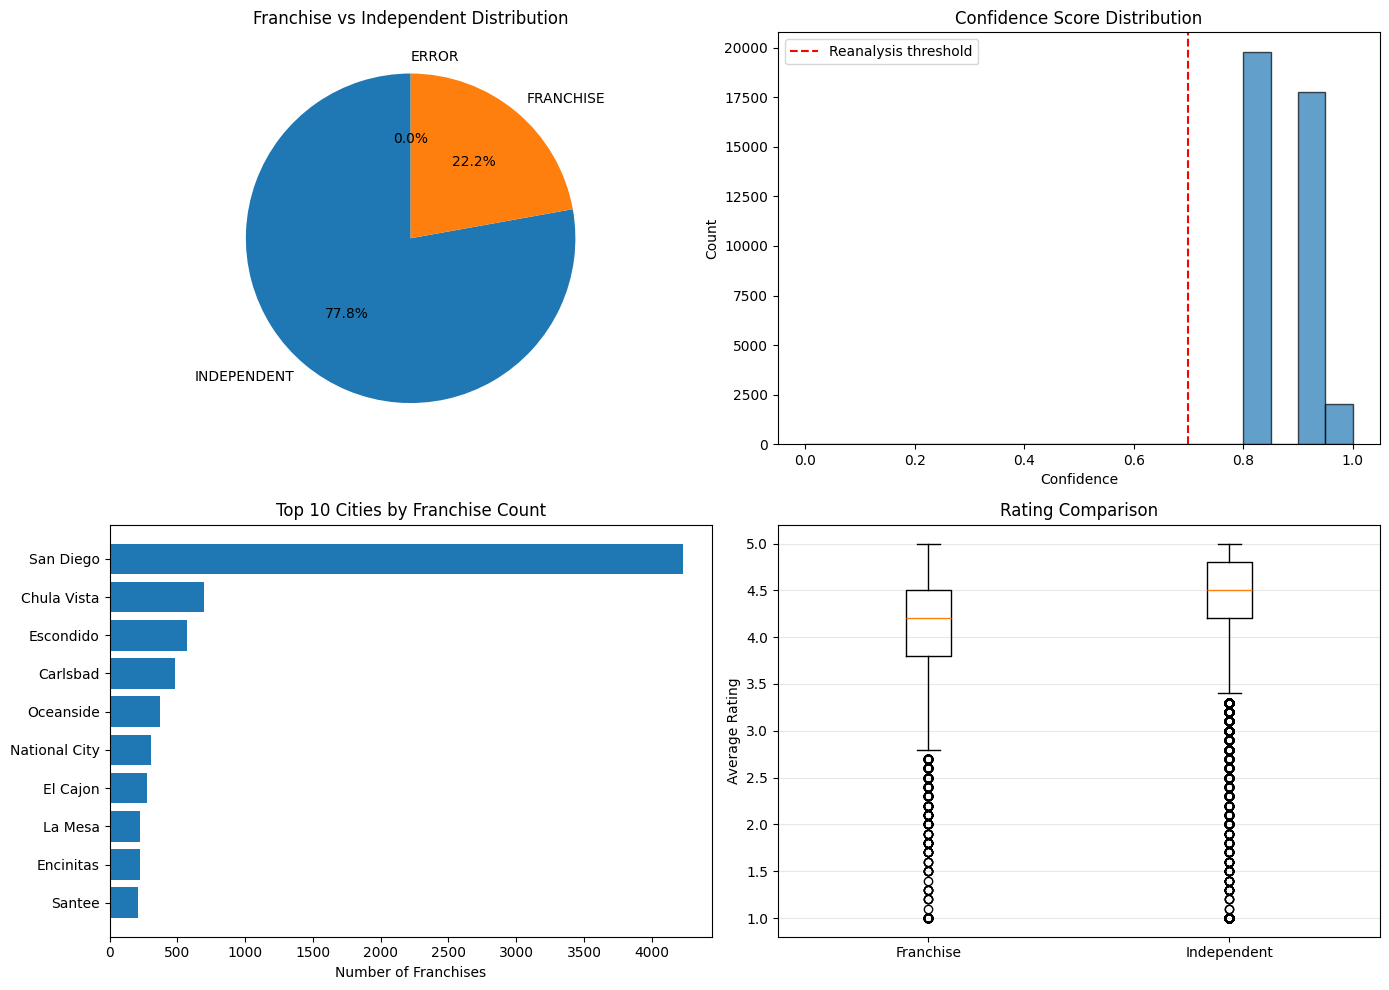

Visualizations complete.


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Franchise vs Independent pie chart
classification_counts = df['franchise'].value_counts()
axes[0, 0].pie(classification_counts.values, labels=classification_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Franchise vs Independent Distribution')

# 2. Confidence distribution histogram
axes[0, 1].hist(df['confidence'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0.7, color='red', linestyle='--', label='Reanalysis threshold')
axes[0, 1].set_xlabel('Confidence')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Confidence Score Distribution')
axes[0, 1].legend()

# 3. Top 10 cities by franchise count
top_cities = df[df['franchise'] == 'FRANCHISE'].groupby('city').size().sort_values(ascending=False).head(10)
axes[1, 0].barh(range(len(top_cities)), top_cities.values)
axes[1, 0].set_yticks(range(len(top_cities)))
axes[1, 0].set_yticklabels(top_cities.index)
axes[1, 0].set_xlabel('Number of Franchises')
axes[1, 0].set_title('Top 10 Cities by Franchise Count')
axes[1, 0].invert_yaxis()

# 4. Rating comparison box plot
rating_data = [franchise_ratings.dropna(), independent_ratings.dropna()]
axes[1, 1].boxplot(rating_data, labels=['Franchise', 'Independent'])
axes[1, 1].set_ylabel('Average Rating')
axes[1, 1].set_title('Rating Comparison')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Visualizations complete.')

## Category-Level Franchise Analysis

Which business categories have the highest franchise rates and which are hardest to classify.

In [17]:
# Extract category-level statistics
category_stats = []

for _, row in df.iterrows():
    if isinstance(row['categories'], list):
        for cat in row['categories']:
            category_stats.append({
                'category': cat,
                'franchise': row['franchise'],
                'confidence': row['confidence']
            })

cat_df = pd.DataFrame(category_stats)

# Categories with highest franchise percentage (min 20 businesses)
cat_counts = cat_df.groupby('category').size()
cat_franchises = cat_df[cat_df['franchise'] == 'FRANCHISE'].groupby('category').size()
cat_pct = (cat_franchises / cat_counts * 100).sort_values(ascending=False)
cat_pct_filtered = cat_pct[cat_counts >= 20]

print('Top 10 Categories by Franchise Percentage (min 20 businesses):')
for cat, pct in cat_pct_filtered.head(10).items():
    print(f'{cat}: {pct:.1f}% ({cat_franchises.get(cat, 0)}/{cat_counts[cat]} businesses)')

# Categories with lowest average confidence (hardest to classify)
cat_confidence = cat_df.groupby('category')['confidence'].agg(['mean', 'count']).sort_values('mean')
cat_confidence_filtered = cat_confidence[cat_confidence['count'] >= 20]

print('\nTop 10 Hardest Categories to Classify (lowest confidence, min 20 businesses):')
for cat, row in cat_confidence_filtered.head(10).iterrows():
    print(f'{cat}: {row["mean"]:.3f} avg confidence ({int(row["count"])} businesses)')

Top 10 Categories by Franchise Percentage (min 20 businesses):
School supply store: 100.0% (82/82 businesses)
Movie rental kiosk: 100.0% (39/39 businesses)
Discount supermarket: 98.0% (49/50 businesses)
Paintings store: 96.4% (27/28 businesses)
Telephone company: 95.6% (151/158 businesses)
Fuel pump: 95.1% (39/41 businesses)
Movie rental store: 95.1% (39/41 businesses)
Electronic parts supplier: 94.8% (127/134 businesses)
Department store: 93.6% (191/204 businesses)
Office supply store: 93.6% (102/109 businesses)

Top 10 Hardest Categories to Classify (lowest confidence, min 20 businesses):
Game store: 0.808 avg confidence (25 businesses)
Shopping mall: 0.817 avg confidence (437 businesses)
Work clothes store: 0.836 avg confidence (22 businesses)
Halal restaurant: 0.840 avg confidence (29 businesses)
Greek restaurant: 0.840 avg confidence (78 businesses)
Temp agency: 0.843 avg confidence (34 businesses)
Mexican grocery store: 0.845 avg confidence (28 businesses)
European restaurant: 0.

## Franchise Chains Analysis

Multi-location franchise chains and their distribution patterns.

In [18]:
# Analyze franchise chains with multiple locations
franchise_df = df[df['franchise'] == 'FRANCHISE']
chain_counts = franchise_df.groupby('name').size().sort_values(ascending=False)

print('Top 15 Franchise Chains by Location Count:')
for rank, (name, count) in enumerate(chain_counts.head(15).items(), 1):
    print(f'{rank:2}. {name}: {count} locations')

# Multi-location vs single-location analysis
multi_location = (chain_counts > 1).sum()
single_location = (chain_counts == 1).sum()

print(f'\nFranchise Chain Distribution:')
print(f'Multi-location chains: {multi_location} ({multi_location/(multi_location+single_location)*100:.1f}%)')
print(f'Single-location franchises: {single_location} ({single_location/(multi_location+single_location)*100:.1f}%)')
print(f'\nAverage locations per chain: {chain_counts.mean():.2f}')
print(f'Median locations per chain: {chain_counts.median():.0f}')

Top 15 Franchise Chains by Location Count:
 1. Starbucks: 258 locations
 2. Subway: 144 locations
 3. 7-Eleven: 136 locations
 4. Jack in the Box: 86 locations
 5. McDonald's: 83 locations
 6. ARCO: 82 locations
 7. Shell: 79 locations
 8. T-Mobile: 75 locations
 9. CVS: 59 locations
10. Metro by T-Mobile: 55 locations
11. Citibank ATM: 54 locations
12. The UPS Store: 51 locations
13. Wells Fargo Bank: 47 locations
14. Panda Express: 46 locations
15. Chevron: 46 locations

Franchise Chain Distribution:
Multi-location chains: 803 (26.0%)
Single-location franchises: 2282 (74.0%)

Average locations per chain: 2.85
Median locations per chain: 1


## Rating Tiers Analysis

Performance comparison across different rating tiers.

In [19]:
# Filter businesses with ratings
df_rated = df[df['avg_rating'].notna()].copy()

# Create rating tiers
df_rated['rating_tier'] = pd.cut(df_rated['avg_rating'], 
                                   bins=[0, 2.5, 3.5, 5.0],
                                   labels=['Low (1-2.5)', 'Medium (2.5-3.5)', 'High (3.5-5)'])

# Franchise vs independent by rating tier
tier_franchise = df_rated.groupby(['rating_tier', 'franchise']).size().unstack(fill_value=0)

print('Rating Tier Distribution:')
print(tier_franchise)

# Percentage breakdown
print('\nFranchise Percentage by Rating Tier:')
for tier in tier_franchise.index:
    if 'FRANCHISE' in tier_franchise.columns and 'INDEPENDENT' in tier_franchise.columns:
        total = tier_franchise.loc[tier].sum()
        franchise_pct = tier_franchise.loc[tier, 'FRANCHISE'] / total * 100 if total > 0 else 0
        print(f'{tier}: {franchise_pct:.1f}% franchise ({tier_franchise.loc[tier, "FRANCHISE"]}/{total})')

Rating Tier Distribution:
franchise         ERROR  FRANCHISE  INDEPENDENT
rating_tier                                    
Low (1-2.5)           0        262          638
Medium (2.5-3.5)      0       1092         1986
High (3.5-5)          2       7423        28168

Franchise Percentage by Rating Tier:
Low (1-2.5): 29.1% franchise (262/900)
Medium (2.5-3.5): 35.5% franchise (1092/3078)
High (3.5-5): 20.9% franchise (7423/35593)


C:\Users\Home\AppData\Local\Temp\ipykernel_3620\3801238257.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_franchise = df_rated.groupby(['rating_tier', 'franchise']).size().unstack(fill_value=0)


## Confidence Analysis by Attributes

Which geographic areas and categories are hardest to classify.

In [20]:
# Cities with lowest average confidence (min 20 businesses)
city_confidence = df.groupby('city').agg({
    'confidence': ['mean', 'count']
}).sort_values(('confidence', 'mean'))

city_confidence_filtered = city_confidence[city_confidence[('confidence', 'count')] >= 20]

print('Top 10 Cities with Lowest Classification Confidence (min 20 businesses):')
for city, row in city_confidence_filtered.head(10).iterrows():
    print(f'{city}: {row[("confidence", "mean")]:.3f} avg confidence ({int(row[("confidence", "count")])} businesses)')

# Advanced model usage by category
print('\nNote: Low confidence (<0.7) triggers advanced model reanalysis')
low_conf_count = (df['confidence'] < 0.7).sum()
print(f'Total businesses requiring advanced model: {low_conf_count} ({low_conf_count/len(df)*100:.1f}%)')

Top 10 Cities with Lowest Classification Confidence (min 20 businesses):
Rancho Santa Fe: 0.874 avg confidence (56 businesses)
Del Mar: 0.877 avg confidence (294 businesses)
Vista: 0.878 avg confidence (540 businesses)
San Marcos: 0.878 avg confidence (707 businesses)
San Diego: 0.878 avg confidence (20526 businesses)
Imperial Beach: 0.878 avg confidence (250 businesses)
Solana Beach: 0.879 avg confidence (293 businesses)
La Jolla: 0.879 avg confidence (982 businesses)
Coronado: 0.879 avg confidence (366 businesses)
Carlsbad: 0.880 avg confidence (1780 businesses)

Note: Low confidence (<0.7) triggers advanced model reanalysis
Total businesses requiring advanced model: 2 (0.0%)


## ZIP Code Analysis

Franchise density and patterns by ZIP code.

In [21]:
# Filter businesses with ZIP codes
df_with_zip = df[df['zip'].notna()].copy()

# ZIP code franchise statistics
zip_counts = df_with_zip.groupby('zip').size()
zip_franchises = df_with_zip[df_with_zip['franchise'] == 'FRANCHISE'].groupby('zip').size()
zip_pct = (zip_franchises / zip_counts * 100).sort_values(ascending=False)

# High franchise ZIPs (min 10 businesses)
zip_pct_filtered = zip_pct[zip_counts >= 10]

print('Top 10 ZIP Codes by Franchise Percentage (min 10 businesses):')
for zipcode, pct in zip_pct_filtered.head(10).items():
    print(f'{zipcode}: {pct:.1f}% franchise ({zip_franchises.get(zipcode, 0)}/{zip_counts[zipcode]} businesses)')

# ZIP codes with most businesses
print('\nTop 10 ZIP Codes by Business Count:')
for zipcode, count in zip_counts.sort_values(ascending=False).head(10).items():
    franchise_count = zip_franchises.get(zipcode, 0)
    pct = franchise_count / count * 100
    print(f'{zipcode}: {count} businesses ({pct:.1f}% franchise)')

Top 10 ZIP Codes by Franchise Percentage (min 10 businesses):
91915: 53.8% franchise (142/264 businesses)
92173: 46.5% franchise (200/430 businesses)
92135: 44.4% franchise (8/18 businesses)
92122: 43.0% franchise (219/509 businesses)
92108: 39.4% franchise (456/1158 businesses)
92009: 37.9% franchise (131/346 businesses)
92128: 35.6% franchise (190/533 businesses)
92145: 34.2% franchise (13/38 businesses)
92134: 33.3% franchise (4/12 businesses)
91914: 29.6% franchise (58/196 businesses)

Top 10 ZIP Codes by Business Count:
92101: 2612 businesses (17.9% franchise)
92111: 1339 businesses (21.1% franchise)
92109: 1233 businesses (14.7% franchise)
92110: 1174 businesses (23.9% franchise)
92108: 1158 businesses (39.4% franchise)
92025: 1137 businesses (26.0% franchise)
92121: 1101 businesses (12.3% franchise)
92020: 1091 businesses (25.2% franchise)
91950: 1042 businesses (29.6% franchise)
92054: 1036 businesses (22.4% franchise)


## Business Characteristics Comparison

Key differences between franchises and independent businesses.

In [22]:
# Average number of categories
df['category_count'] = df['categories'].apply(lambda x: len(x) if isinstance(x, list) else 0)

franchise_cat_avg = df[df['franchise'] == 'FRANCHISE']['category_count'].mean()
independent_cat_avg = df[df['franchise'] == 'INDEPENDENT']['category_count'].mean()

print('Average Number of Categories:')
print(f'Franchises: {franchise_cat_avg:.2f}')
print(f'Independent: {independent_cat_avg:.2f}')
print(f'Difference: {franchise_cat_avg - independent_cat_avg:+.2f}')

# Classification confidence comparison
print('\nClassification Confidence:')
franchise_conf = df[df['franchise'] == 'FRANCHISE']['confidence'].mean()
independent_conf = df[df['franchise'] == 'INDEPENDENT']['confidence'].mean()
print(f'Franchises: {franchise_conf:.3f}')
print(f'Independent: {independent_conf:.3f}')
print(f'Difference: {franchise_conf - independent_conf:+.3f}')

# Businesses with specific data
print('\nData Completeness:')
print(f'Businesses with ratings: {df["avg_rating"].notna().sum()} ({df["avg_rating"].notna().sum()/len(df)*100:.1f}%)')
print(f'Businesses with categories: {df["category_count"].gt(0).sum()} ({df["category_count"].gt(0).sum()/len(df)*100:.1f}%)')
print(f'Businesses with blockgroup: {df["blockgroup"].notna().sum()} ({df["blockgroup"].notna().sum()/len(df)*100:.1f}%)')

Average Number of Categories:
Franchises: 3.66
Independent: 2.08
Difference: +1.57

Classification Confidence:
Franchises: 0.925
Independent: 0.867
Difference: +0.058

Data Completeness:
Businesses with ratings: 39571 (99.9%)
Businesses with categories: 39424 (99.6%)
Businesses with blockgroup: 0 (0.0%)


## Missing Data Analysis

Overview of data completeness and missing values across key fields.

In [23]:
# Calculate missing data for each field
missing_data = {
    'Field': [],
    'Missing Count': [],
    'Missing %': [],
    'Present Count': [],
    'Present %': []
}

fields_to_check = ['name', 'address', 'city', 'zip', 'latitude', 'longitude', 
                   'avg_rating', 'blockgroup', 'categories']

for field in fields_to_check:
    if field == 'categories':
        # For categories, check if list is empty
        missing = (~df['categories'].apply(lambda x: isinstance(x, list) and len(x) > 0)).sum()
    else:
        missing = df[field].isna().sum()
    
    present = len(df) - missing
    missing_pct = (missing / len(df)) * 100
    present_pct = (present / len(df)) * 100
    
    missing_data['Field'].append(field)
    missing_data['Missing Count'].append(missing)
    missing_data['Missing %'].append(f'{missing_pct:.1f}%')
    missing_data['Present Count'].append(present)
    missing_data['Present %'].append(f'{present_pct:.1f}%')

missing_df = pd.DataFrame(missing_data)
print('Data Completeness Summary:')
print(missing_df.to_string(index=False))

# Impact on franchise classification
print('\nImpact of Missing Ratings on Classification:')
no_rating = df[df['avg_rating'].isna()]
print(f'Businesses without ratings: {len(no_rating)}')
if len(no_rating) > 0:
    no_rating_franchise_pct = (no_rating['franchise'] == 'FRANCHISE').sum() / len(no_rating) * 100
    print(f'Franchise rate (no rating): {no_rating_franchise_pct:.1f}%')
    
has_rating = df[df['avg_rating'].notna()]
if len(has_rating) > 0:
    has_rating_franchise_pct = (has_rating['franchise'] == 'FRANCHISE').sum() / len(has_rating) * 100
    print(f'Franchise rate (has rating): {has_rating_franchise_pct:.1f}%')

Data Completeness Summary:
     Field  Missing Count Missing %  Present Count Present %
      name              0      0.0%          39593    100.0%
   address              0      0.0%          39593    100.0%
      city             66      0.2%          39527     99.8%
       zip              0      0.0%          39593    100.0%
  latitude              0      0.0%          39593    100.0%
 longitude              0      0.0%          39593    100.0%
avg_rating             22      0.1%          39571     99.9%
blockgroup          39593    100.0%              0      0.0%
categories            169      0.4%          39424     99.6%

Impact of Missing Ratings on Classification:
Businesses without ratings: 22
Franchise rate (no rating): 0.0%
Franchise rate (has rating): 22.2%


## Advanced Visualizations

Additional charts for deeper insights.

C:\Users\Home\AppData\Local\Temp\ipykernel_3620\1048253569.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_data = df_rated.groupby(['rating_tier', 'franchise']).size().unstack(fill_value=0)


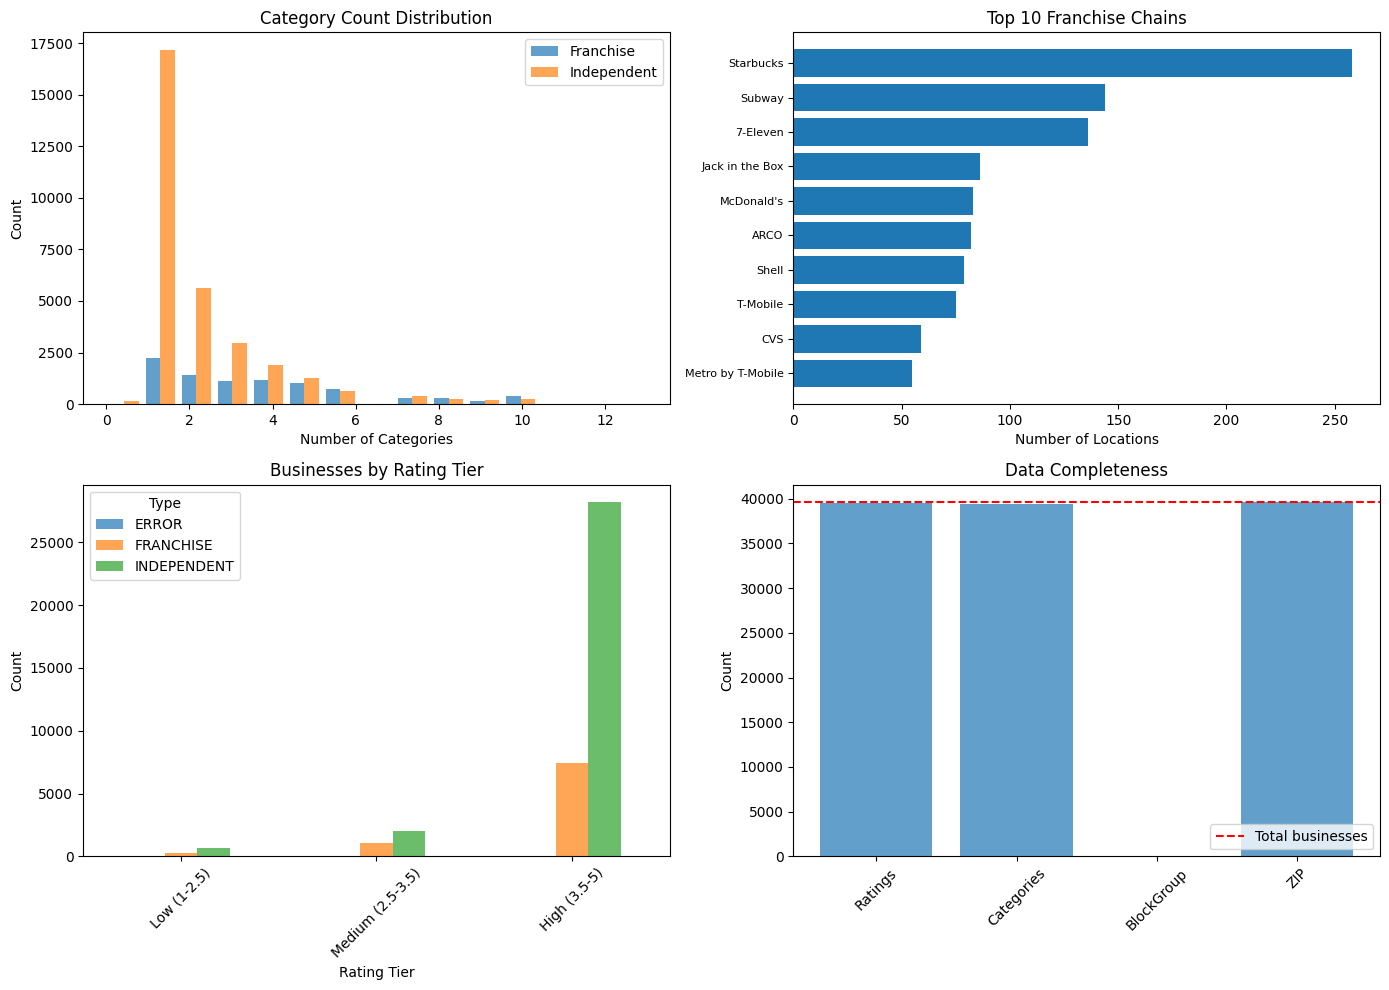

Advanced visualizations complete.


In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Category count distribution
axes[0, 0].hist([df[df['franchise'] == 'FRANCHISE']['category_count'],
                 df[df['franchise'] == 'INDEPENDENT']['category_count']],
                bins=15, label=['Franchise', 'Independent'], alpha=0.7)
axes[0, 0].set_xlabel('Number of Categories')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Category Count Distribution')
axes[0, 0].legend()

# 2. Franchise chains - top 10
franchise_df = df[df['franchise'] == 'FRANCHISE']
top_chains = franchise_df.groupby('name').size().sort_values(ascending=False).head(10)
axes[0, 1].barh(range(len(top_chains)), top_chains.values)
axes[0, 1].set_yticks(range(len(top_chains)))
axes[0, 1].set_yticklabels(top_chains.index, fontsize=8)
axes[0, 1].set_xlabel('Number of Locations')
axes[0, 1].set_title('Top 10 Franchise Chains')
axes[0, 1].invert_yaxis()

# 3. Rating tier comparison
if len(df_rated) > 0:
    tier_data = df_rated.groupby(['rating_tier', 'franchise']).size().unstack(fill_value=0)
    tier_data.plot(kind='bar', ax=axes[1, 0], alpha=0.7)
    axes[1, 0].set_xlabel('Rating Tier')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Businesses by Rating Tier')
    axes[1, 0].legend(title='Type')
    axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Data completeness
completeness = {
    'Ratings': df['avg_rating'].notna().sum(),
    'Categories': df['category_count'].gt(0).sum(),
    'BlockGroup': df['blockgroup'].notna().sum(),
    'ZIP': df['zip'].notna().sum()
}
axes[1, 1].bar(completeness.keys(), completeness.values(), alpha=0.7)
axes[1, 1].axhline(y=len(df), color='red', linestyle='--', label='Total businesses')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Data Completeness')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Advanced visualizations complete.')